In [15]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [16]:
def process_data_final(file_path, num_points=100):
    if not os.path.exists(file_path): 
        raise FileNotFoundError(f'File not found: {file_path}')
        
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    df.columns = df.columns.str.strip()
    df['Model_ID'] = pd.to_numeric(df['Model_ID'], errors='coerce')
    
    ids = df['Model_ID'].unique()
    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    for uid in ids:
        try:
            case_data = df[df['Model_ID'] == uid].sort_values('Time (s)')
            inputs = case_data[['Length', 'Diameter', 'Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']].iloc[0].values
            t = case_data['Time (s)'].values
            
            if len(t) < 2 or t[-1] <= 0 or np.any(inputs <= 0): 
                continue

            thrust = case_data['Thrust (N)'].fillna(0).values
            pressure = case_data['Pressure (MPa)'].fillna(0).values

            if len(thrust) > 7:
                thrust = savgol_filter(thrust, window_length=7, polyorder=3)
                pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            x_new = np.linspace(t[0], t[-1], num_points)
            X.append(inputs)
            y_thrust.append(interp1d(t, thrust, kind='linear', fill_value='extrapolate')(x_new))
            y_pressure.append(interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new))
            y_scalars.append([case_data['ISP (s)'].iloc[0], case_data['Total Impulse (Ns)'].iloc[0], t[-1], np.max(thrust)])
            
        except Exception: 
            continue
        
    return np.array(X), np.array(y_thrust), np.array(y_pressure), np.array(y_scalars)

# استدعاء ملف الـ CSV من نفس المسار القديم
file_path = '/kaggle/input/datasets/mahmoudabdelrazekk/bates1/Final_data_bates.csv'
X, yt, yp, ys = process_data_final(file_path) 
X, yt, yp, ys = X.astype(float), yt.astype(float), yp.astype(float), ys.astype(float)
min_s = min(len(X), len(yt), len(yp), len(ys))
X, yt, yp, ys = X[:min_s], yt[:min_s], yp[:min_s], ys[:min_s]

print(f"The data has been loaded successfully {len(X)} cases.")

The data has been loaded successfully 4011 cases.


In [17]:
X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = train_test_split(
    X, yt, yp, ys, test_size=0.15, random_state=42
)

# الأبعاد (X) ستكون هي المخرجات (Y) في هذا الموديل العكسي
# بدلاً من RobustScaler استخدم MinMaxScaler للأبعاد (Y في الموديل العكسي)
from sklearn.preprocessing import MinMaxScaler

s_X = MinMaxScaler() # التعديل هنا
X_tr_s = s_X.fit_transform(X_train)
X_te_s = s_X.transform(X_test)

# منحنيات الأداء والقيم الثابتة ستكون هي المدخلات
s_yt, s_yp, s_ys = StandardScaler(), StandardScaler(), StandardScaler()

yt_tr_s = s_yt.fit_transform(yt_train)
yp_tr_s = s_yp.fit_transform(yp_train)
ys_tr_s = s_ys.fit_transform(ys_train)

yt_te_s = s_yt.transform(yt_test)
yp_te_s = s_yp.transform(yp_test)
ys_te_s = s_ys.transform(ys_test)

# حفظ الـ Scalers لاستخدامها عند التنبؤ بأبعاد لمحركات جديدة
joblib.dump(s_X, 'scaler_dimensions_inv.pkl')
joblib.dump(s_yt, 'scaler_thrust_inv.pkl')
joblib.dump(s_yp, 'scaler_pressure_inv.pkl')
joblib.dump(s_ys, 'scaler_scalars_inv.pkl')

['scaler_scalars_inv.pkl']

In [43]:
def build_inverse_model_fixed():
    # 1. طبقات الإدخال (Inputs)
    input_thrust = layers.Input(shape=(100,), name='Thrust_Profile')
    input_pressure = layers.Input(shape=(100,), name='Pressure_Profile')
    input_scalars = layers.Input(shape=(4,), name='Scalars')

    # 2. معالجة منحنى الدفع (استخدام ELU بدلاً من ReLU وبدون BatchNormalization)
    x_t = layers.Dense(128, activation='elu')(input_thrust)
    x_t = layers.Dense(64, activation='elu')(x_t)

    # 3. معالجة منحنى الضغط
    x_p = layers.Dense(128, activation='elu')(input_pressure)
    x_p = layers.Dense(64, activation='elu')(x_p)

    # 4. معالجة القيم الثابتة
    x_s = layers.Dense(32, activation='elu')(input_scalars)

    # 5. دمج المسارات الثلاثة
    merged = layers.Concatenate()([x_t, x_p, x_s])

    # 6. الطبقات المشتركة لاستنباط الأبعاد
    shared = layers.Dense(256, activation='elu')(merged)
    shared = layers.Dropout(0.15)(shared) # ضروري جداً لعمل MC Dropout
    
    shared = layers.Dense(128, activation='elu')(shared)
    shared = layers.Dropout(0.15)(shared) # طبقة إضافية لضمان حساب الـ Uncertainty بدقة
    
    shared = layers.Dense(64, activation='elu')(shared)

    # 7. طبقة المخرجات
    # استخدام sigmoid يضمن أن المخرجات دائماً بين 0 و 1 (مما يمنع الأبعاد السالبة تماماً)
    output_dims = layers.Dense(5, activation='sigmoid', name='Dimensions_Output')(shared)

    # إنشاء الموديل وتجميعه
    model = Model(inputs=[input_thrust, input_pressure, input_scalars], outputs=output_dims)
    
    # نستخدم MAE كـ Loss أساسي هنا لأنه يجبر الموديل على تتبع الأرقام بدقة أكبر من Huber
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mae', metrics=['mse'])
    
    return model

inverse_model = build_inverse_model_fixed()
inverse_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Thrust_Profile      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure_Profile    │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │     12,928 │ Thrust_Profile[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 128)       │     12,928 │ Pressure_Profile… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalars             │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      8,256 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 64)        │      8,256 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 32)        │        160 │ Scalars[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 160)       │          0 │ dense_25[0][0],   │
│ (Concatenate)       │                   │            │ dense_27[0][0],   │
│                     │                   │            │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 256)       │     41,216 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dimensions_Output   │ (None, 5)         │        325 │ dense_31[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,221 (489.14 KB)

 Trainable params: 125,221 (489.14 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

# تدريب الموديل العكسي
history_inv = inverse_model.fit(
    x=[yt_tr_s, yp_tr_s, ys_tr_s],  # المدخلات: منحنيات وأرقام الأداء
    y=X_tr_s,                       # المخرجات: الأبعاد المقيسة بـ RobustScaler
    validation_split=0.15,
    epochs=300, 
    batch_size=32, 
    verbose=1,
    callbacks=[early_stopping, lr_scheduler]
)


Epoch 1/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1323 - mse: 0.0319 - val_loss: 0.0475 - val_mse: 0.0036 - learning_rate: 5.0000e-04
Epoch 2/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0563 - mse: 0.0053 - val_loss: 0.0345 - val_mse: 0.0018 - learning_rate: 5.0000e-04
Epoch 3/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0443 - mse: 0.0032 - val_loss: 0.0332 - val_mse: 0.0018 - learning_rate: 5.0000e-04
Epoch 4/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0420 - mse: 0.0029 - val_loss: 0.0308 - val_mse: 0.0016 - learning_rate: 5.0000e-04
Epoch 5/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0379 - mse: 0.0024 - val_loss: 0.0287 - val_mse: 0.0013 - learning_rate: 5.0000e-04
Epoch 6/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0370 - mse: 0.0023 - val_loss: 0.0315 - val_mse: 0.0016 - learning_rate: 5.0000e-04
Epoch 7/300
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0338 - mse: 0.0019 - val_loss: 0.0225 - val_mse: 8.5384e-04 - learni


Test Loss (Huber): 0.0046
Test MAE: 0.0001


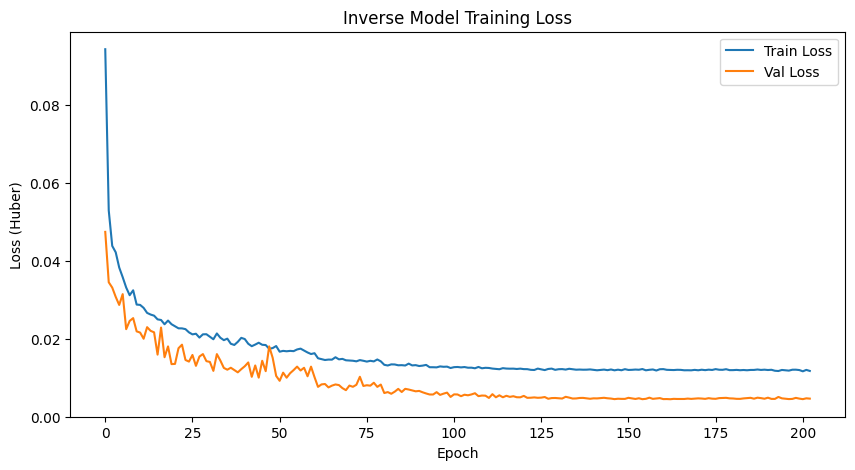

In [45]:
# تقييم الموديل على بيانات الاختبار
test_loss, test_mae = inverse_model.evaluate([yt_te_s, yp_te_s, ys_te_s], X_te_s, verbose=0)
print(f"\nTest Loss (Huber): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# رسم منحنى التعلّم
plt.figure(figsize=(10, 5))
plt.plot(history_inv.history['loss'], label='Train Loss')
plt.plot(history_inv.history['val_loss'], label='Val Loss')
plt.title('Inverse Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.show()

Final Train Loss : 0.01175
Final Val Loss   : 0.00464
Ratio (val/train): 0.39x

--- Inverse Model Evaluation ---
  Length         : MAE = 0.2235  |  MAPE = 0.60%
  Diameter       : MAE = 0.0731  |  MAPE = 0.57%
  Core_Diameter  : MAE = 0.0375  |  MAPE = 0.77%
  Throat_Diameter: MAE = 0.0034  |  MAPE = 0.21%
  Exit_Diameter  : MAE = 0.0047  |  MAPE = 0.19%


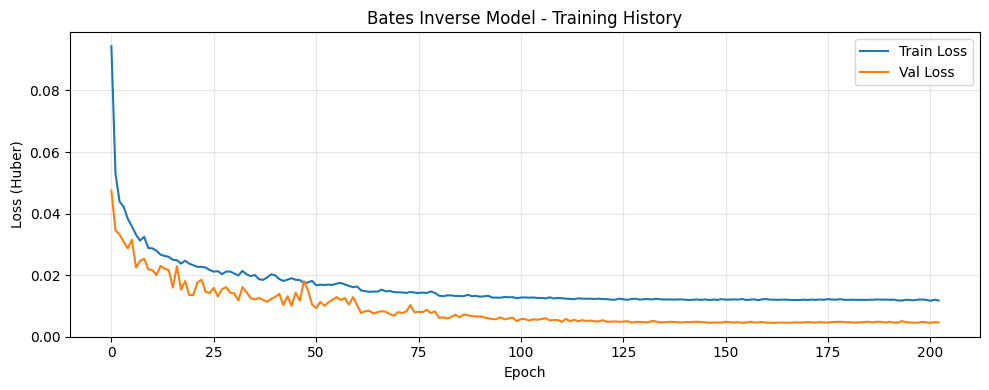

In [46]:
# 1. طباعة الخسارة النهائية من تاريخ التدريب (history_inv)
train_loss = history_inv.history['loss'][-1]
val_loss   = history_inv.history['val_loss'][-1]
print(f"Final Train Loss : {train_loss:.5f}")
print(f"Final Val Loss   : {val_loss:.5f}")
print(f"Ratio (val/train): {val_loss / train_loss:.2f}x")

# 2. إجراء التنبؤ على بيانات الاختبار (لاحظ أن المدخلات هي المنحنيات والقيم الثابتة)
y_inv_pred_s = inverse_model.predict([yt_te_s, yp_te_s, ys_te_s], verbose=0)

# عكس التقييس (Inverse Transform) للحصول على الأبعاد الحقيقية
# نستخدم s_X لأنه الـ Scaler الذي قمنا بتقييس الأبعاد به
y_inv_pred   = s_X.inverse_transform(y_inv_pred_s)

# الأبعاد الحقيقية للاختبار (غير المقيسة)
y_inv_test   = X_test 

# 3. حساب وعرض نسبة الخطأ لكل بُعد (MAE و MAPE)
cols = ['Length', 'Diameter', 'Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']
print("\n--- Inverse Model Evaluation ---")
for i, col in enumerate(cols):
    # حساب متوسط الخطأ المطلق (MAE)
    mae  = np.mean(np.abs(y_inv_pred[:, i] - y_inv_test[:, i]))
    
    # حساب متوسط نسبة الخطأ المئوية (MAPE)
    mape = np.mean(np.abs(
        (y_inv_pred[:, i] - y_inv_test[:, i]) /
        (y_inv_test[:, i] + 1e-8) # إضافة رقم صغير جداً لتجنب القسمة على صفر
    )) * 100
    
    print(f"  {col:<15}: MAE = {mae:.4f}  |  MAPE = {mape:.2f}%")

# 4. رسم منحنى التدريب (Training History Plot)
plt.figure(figsize=(10, 4))
plt.plot(history_inv.history['loss'],     label='Train Loss')
plt.plot(history_inv.history['val_loss'], label='Val Loss')
plt.title('Bates Inverse Model - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


🎯 MC Dropout Uncertainty — Sample #100
Dimension        Predicted       ±σ     Actual     Err% Confidence
Length              30.013    0.000     30.000     0.0%  🟢 High
Outer Dia           14.036    0.002     14.000     0.3%  🟢 High
Inner Dia            6.166    0.003      6.200     0.5%  🟢 High
Throat Dia           1.704    0.014      1.700     0.3%  🟢 High
Exit Dia             2.551    0.011      2.550     0.0%  🟢 High


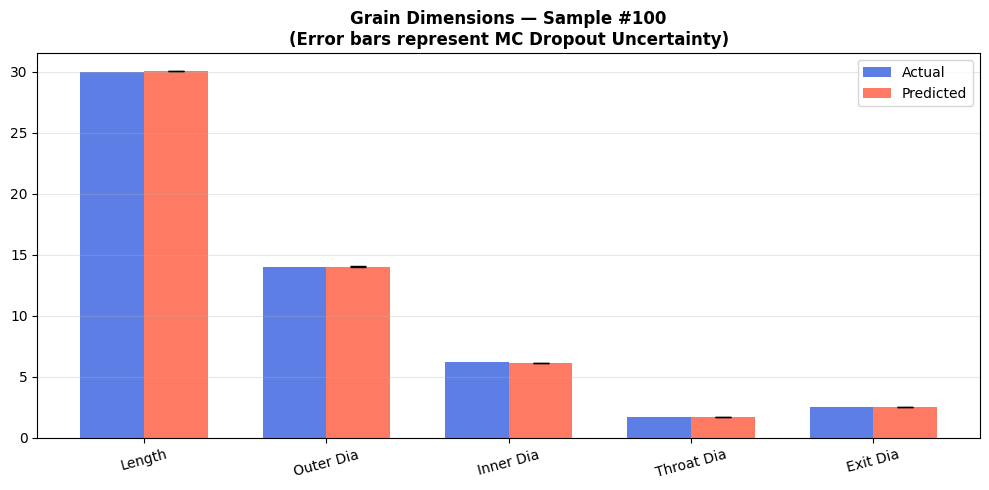


🎯 MC Dropout Uncertainty — Sample #9
Dimension        Predicted       ±σ     Actual     Err% Confidence
Length              20.122    0.000     20.000     0.6%  🟢 High
Outer Dia           12.991    0.002     13.000     0.1%  🟢 High
Inner Dia            5.803    0.003      5.800     0.0%  🟢 High
Throat Dia           1.502    0.021      1.500     0.1%  🟢 High
Exit Dia             2.250    0.014      2.250     0.0%  🟢 High


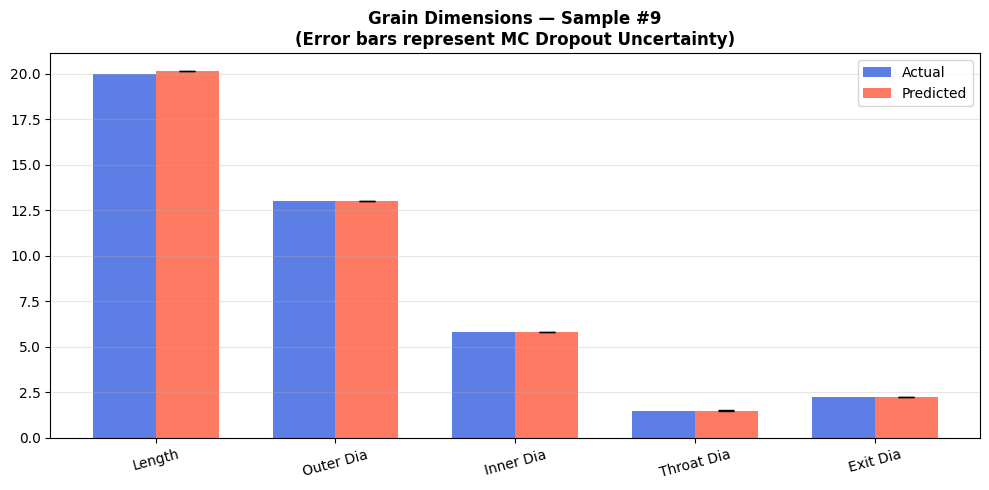


🎯 MC Dropout Uncertainty — Sample #7
Dimension        Predicted       ±σ     Actual     Err% Confidence
Length              50.074    0.000     50.000     0.1%  🟢 High
Outer Dia           10.395    0.001     10.500     1.0%  🟢 High
Inner Dia            3.584    0.002      3.600     0.4%  🟢 High
Throat Dia           1.600    0.021      1.600     0.0%  🟢 High
Exit Dia             2.402    0.014      2.400     0.1%  🟢 High


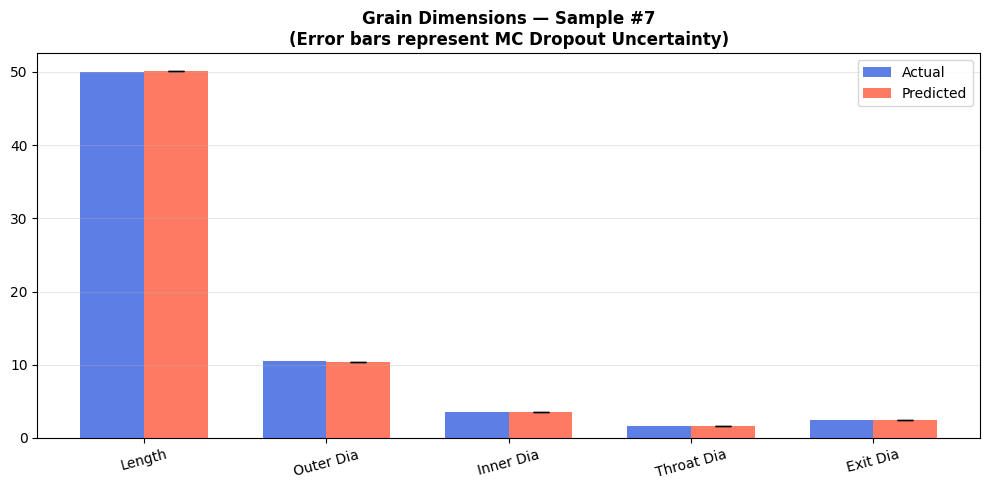

In [51]:
@tf.function
def predict_with_dropout(inputs):
    # 'training=True' forces Dropout layers to remain active during prediction
    # inputs here will be a list of 3 tensors [thrust, pressure, scalars]
    return inverse_model(inputs, training=True)

# بدلاً من @tf.function التي تفعل الـ Training لكل الموديل
def mc_predict(t_in, p_in, s_in, n_iter=200):
    t_tensor = tf.constant(t_in, dtype=tf.float32)
    p_tensor = tf.constant(p_in, dtype=tf.float32)
    s_tensor = tf.constant(s_in, dtype=tf.float32)
    
    preds = []
    for _ in range(n_iter):
        # نقوم بتمرير training=True كـ argument مباشر لطبقات الـ Dropout فقط عبر الكواليس
        # في الإصدارات الحديثة من TF يفضل عمل الآتي:
        out = inverse_model([t_tensor, p_tensor, s_tensor], training=True) 
        preds.append(out.numpy())
        
    preds_arr = np.stack(preds, axis=0)
    return preds_arr.mean(axis=0), preds_arr.std(axis=0)
def show_uncertainty(sample_idx=0):
    # 1. Extract a single test sample (3 inputs for the inverse model)
    t_s = yt_te_s[sample_idx:sample_idx+1]
    p_s = yp_te_s[sample_idx:sample_idx+1]
    s_s = ys_te_s[sample_idx:sample_idx+1]
    
    # الأبعاد الحقيقية للاختبار (غير مقيسة)
    actual = X_test[sample_idx] 
    
    # 2. Get Monte Carlo predictions (scaled)
    pred_mean_s, pred_std_s = mc_predict(t_s, p_s, s_s, n_iter=200)
    
    # 3. Inverse transform the outputs
    # Inverse the mean prediction back to original dimensions
    pred_vals = s_X.inverse_transform(pred_mean_s)[0]
    
    # Inverse the standard deviation
    # Note: std deviation is not affected by centering, only by the scale factor
    pred_unc = pred_std_s[0] * s_X.scale_
    
    DIM_NAMES = ['Length', 'Outer Dia', 'Inner Dia', 'Throat Dia', 'Exit Dia']
    
    # 4. Print the results in a formatted table
    print(f"\n🎯 MC Dropout Uncertainty — Sample #{sample_idx}")
    print("=" * 72)
    print(f"{'Dimension':<15} {'Predicted':>10} {'±σ':>8} {'Actual':>10} "
          f"{'Err%':>8} {'Confidence'}")
    print("=" * 72)
    
    for i, name in enumerate(DIM_NAMES):
        actual_val = actual[i]
        err = abs(pred_vals[i] - actual_val) / (actual_val + 1e-9) * 100
        
        # Coefficient of Variation (CV) to estimate confidence level
        cv   = pred_unc[i] / (abs(pred_vals[i]) + 1e-9) * 100
        conf = "🟢 High" if cv < 5 else ("🟡 Medium" if cv < 15 else "🔴 Low")
        
        print(f"{name:<15} {pred_vals[i]:>10.3f} {pred_unc[i]:>8.3f} "
              f"{actual_val:>10.3f} {err:>7.1f}%  {conf}")
              
    print("=" * 72)

    # 5. Bar chart visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    x     = np.arange(5)
    width = 0.35
    
    # Actual vs Predicted bars
    ax.bar(x - width/2, actual,    width, label='Actual',    color='royalblue', alpha=0.85)
    ax.bar(x + width/2, pred_vals, width, label='Predicted', color='tomato',    alpha=0.85,
           yerr=pred_unc, capsize=6, error_kw={'linewidth': 2})
           
    ax.set_xticks(x)
    ax.set_xticklabels(DIM_NAMES, rotation=15, fontsize=10)
    ax.set_title(f'Grain Dimensions — Sample #{sample_idx}\n'
                 f'(Error bars represent MC Dropout Uncertainty)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'inverse_uncertainty_{sample_idx}.png', dpi=150)
    plt.show()

# Run the function on a few samples
show_uncertainty(100)
show_uncertainty(9)
show_uncertainty(7)


Reading file: /kaggle/input/datasets/mahmoudabdelrazekk/train-rev/1.0.xlsx
  ⚠️ Notice: 'ISP' column not found in file. Using estimated 220s.

  Predicted Bates Grain Dimensions
  Length      (Grain Length)  : 20.0021 
  Outer Dia   (Outer Diameter): 10.9587 
  Inner Dia   (Core Diameter) : 3.7841 
  Throat Dia  (Throat Dia)    : 1.1460 
  Exit Dia    (Exit Diameter) : 1.7667 


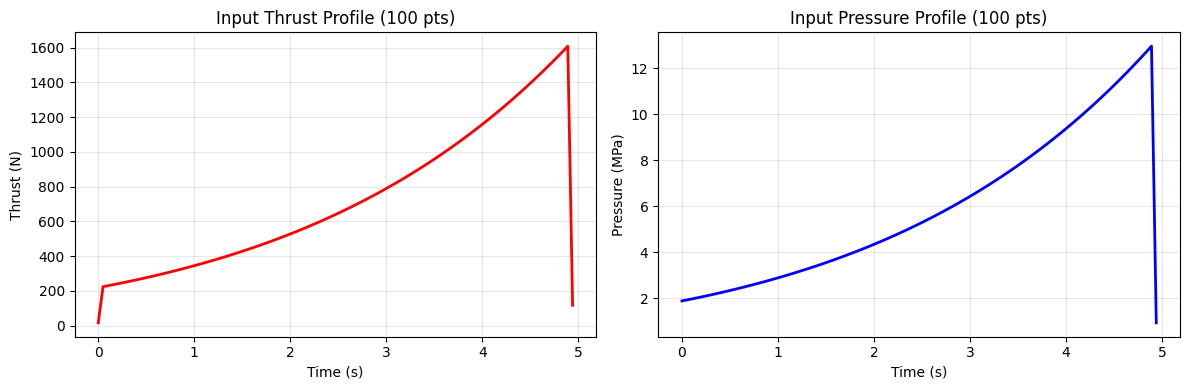

In [50]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid 
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

def predict_dimensions_from_file(file_path):
    """
    Input file can be CSV or Excel (.xlsx, .xls)
    """
    print(f"\nReading file: {file_path}")

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # 1. قراءة الملف بذكاء بناءً على نوعه (Excel أو CSV)
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python', encoding='latin1', on_bad_lines='skip', skip_blank_lines=True)
    
    # 2. إنشاء نظام ذكي للتعرف التلقائي على الأعمدة (بدون التقيد بالمسافات)
    col_map = {}
    for col in df.columns:
        col_clean = str(col).lower().replace(' ', '').replace('_', '').replace('(', '').replace(')', '')
        if 'time' in col_clean or col_clean == 't':
            col_map['time'] = col
        elif 'thrust' in col_clean or col_clean == 'f':
            col_map['thrust'] = col
        elif 'pressure' in col_clean or col_clean == 'p':
            col_map['pressure'] = col
        elif 'isp' in col_clean:
            col_map['isp'] = col

    # 3. التأكد من وجود الأعمدة الأساسية
    if not all(k in col_map for k in ['time', 'thrust', 'pressure']):
        print(f"❌ Columns found in your file: {list(df.columns)}")
        raise ValueError("Could not automatically find 'Time', 'Thrust', or 'Pressure' columns in the file.")

    # 4. سحب البيانات وترتيبها
    df = df.sort_values(col_map['time']).dropna(subset=[col_map['time'], col_map['thrust'], col_map['pressure']])
    
    t        = df[col_map['time']].values
    thrust   = df[col_map['thrust']].values
    pressure = df[col_map['pressure']].values

    # 5. التنعيم (Smoothing)
    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    # 6. الاستيفاء إلى 100 نقطة (Interpolation)
    x_new        = np.linspace(t[0], t[-1], 100)
    thrust_100   = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    pressure_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # 7. حساب القيم الثابتة (Scalars)
    burn_time = t[-1]
    max_thrust = np.max(thrust)
    total_impulse = trapezoid(thrust, t) 
    
    if 'isp' in col_map:
        isp = df[col_map['isp']].iloc[0]
    else:
        print("  ⚠️ Notice: 'ISP' column not found in file. Using estimated 220s.")
        isp = 220.0
        
    scalars = np.array([isp, total_impulse, burn_time, max_thrust])

    # 8. تقييس المدخلات الثلاثة (تأكد من أن s_yt و s_yp و s_ys موجودة في النوت بوك)
    t_scaled = s_yt.transform(thrust_100.reshape(1, -1))
    p_scaled = s_yp.transform(pressure_100.reshape(1, -1))
    s_scaled = s_ys.transform(scalars.reshape(1, -1))

    # 9. التنبؤ بالأبعاد 
    pred_scaled     = inverse_model.predict([t_scaled, p_scaled, s_scaled], verbose=0)
    
    # استخراج الأبعاد من الموديل أولاً (هذا السطر الذي ربما تم حذفه بالخطأ)
    pred_dims       = s_X.inverse_transform(pred_scaled)[0]
    
    # صمام الأمان الهندسي: منع أي رقم سالب
    pred_dims       = np.maximum(pred_dims, 0.1)

    # 10. طباعة النتائج (تم تضمين Exit Dia كما أشرت سابقاً)
    print("\n" + "="*55)
    print("  Predicted Bates Grain Dimensions")
    print("="*55)
    labels = [
        'Length      (Grain Length)  ',
        'Outer Dia   (Outer Diameter)',
        'Inner Dia   (Core Diameter) ',
        'Throat Dia  (Throat Dia)    ',
        'Exit Dia    (Exit Diameter) ' 
    ]
    for label, val in zip(labels, pred_dims):
        print(f"  {label}: {val:.4f} ")
    print("="*55)

    # 11. رسم منحنيات الإدخال
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(x_new, thrust_100, color='red', linewidth=2)
    plt.title('Input Thrust Profile (100 pts)')
    plt.xlabel('Time (s)')
    plt.ylabel('Thrust (N)')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(x_new, pressure_100, color='blue', linewidth=2)
    plt.title('Input Pressure Profile (100 pts)')
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (MPa)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return dict(zip(['Length', 'Outer_Dia', 'Inner_Dia', 'Throat_Dia', 'Exit_Dia'], pred_dims))

# =======================================================
# التشغيل
predicted_dims = predict_dimensions_from_file('/kaggle/input/datasets/mahmoudabdelrazekk/train-rev/1.0.xlsx')

In [53]:
import joblib

# 1. حفظ الموديل العكسي بصيغة Keras الحديثة
inverse_model.save('Bates_inverse_model.keras')

# 2. حفظ الـ Scaler الخاص بالأبعاد (المخرجات)
joblib.dump(s_X, 'bates_inv_scaler_dimensions.pkl')

# 3. حفظ الـ Scalers الخاصة بالأداء (المدخلات الثلاثة)
joblib.dump(s_yt, 'bates_inv_scaler_thrust.pkl')
joblib.dump(s_yp, 'bates_inv_scaler_pressure.pkl')
joblib.dump(s_ys, 'bates_inv_scaler_scalars.pkl')

print("\nInverse Model + All 4 Scalers saved successfully ✅")


Inverse Model + All 4 Scalers saved successfully ✅
